# REZ regions using BARRA-RE2 ensemble-mean wind drought data

This notebook updates the original `REZ_region.ipynb` idea. Instead of plotting only REZ region IDs, it plots the **BARRA-RE2 ensemble-mean climatological annual wind drought days** over REZ areas.

BARRA-RE2 handling:

- The input BARRA file is the one calculated previously from 22 realizations.
- The 22 realizations have already been averaged into one annual field per year.
- The climatological mean is for 1990 to 2025.
- The ERA5 REZ mask is put onto the BARRA grid using nearest-neighbour matching.

Outputs:

1. BARRA-RE2 mean drought days over REZ cells.
2. REZ-region mean drought days, where each REZ region is coloured by its mean BARRA-RE2 value.
3. A bar graph of mean drought days by REZ region.
4. CSV table of REZ-region statistics.

In [1]:
import os
from pathlib import Path

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# =====================
# Paths and settings
# =====================

# BARRA-RE2 annual ensemble-mean file calculated previously
barra_file = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/BARRA_RE2_P20_3day_annual_wind_drought_days_ensemble_mean_1990_2025.nc"

# REZ mask used in your ERA5 notebooks
rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"

# Output folder
output_dir = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/rez_region_analysis"
os.makedirs(output_dir, exist_ok=True)

# Australia extent
lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

# Plot levels, same style as the wind drought frequency figure
levels = np.arange(3, 42, 3)

print("BARRA file:", barra_file)
print("REZ file  :", rez_file)
print("Output dir:", output_dir)

BARRA file: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/BARRA_RE2_P20_3day_annual_wind_drought_days_ensemble_mean_1990_2025.nc
REZ file  : /g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc
Output dir: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/rez_region_analysis


In [3]:
# =====================
# Helper: standardise spatial coordinate names
# =====================
def standardise_lon_lat(da):
    """
    Rename common coordinate/dimension names to lon and lat.
    """
    rename = {}

    for old in ["longitude", "x"]:
        if old in da.dims or old in da.coords:
            rename[old] = "lon"

    for old in ["latitude", "y"]:
        if old in da.dims or old in da.coords:
            rename[old] = "lat"

    if rename:
        da = da.rename(rename)

    return da


def crop_aus(da):
    """
    Crop to Australia extent using lon/lat coordinates.
    """
    return da.where(
        (da["lon"] >= lon_min) & (da["lon"] <= lon_max) &
        (da["lat"] >= lat_min) & (da["lat"] <= lat_max),
        drop=True
    )

In [4]:
# =====================
# Load BARRA-RE2 ensemble-mean data
# =====================
ds_barra = xr.open_dataset(barra_file, engine="netcdf4", decode_times=True)

print(ds_barra)
print("Variables:", list(ds_barra.data_vars))

# Prefer the pre-calculated climatological field.
# If it is not available, calculate it from annual values.
if "climatological_wind_drought_days" in ds_barra.data_vars:
    barra_mean = ds_barra["climatological_wind_drought_days"]

elif "annual_wind_drought_days_ensemble_mean" in ds_barra.data_vars:
    barra_mean = ds_barra["annual_wind_drought_days_ensemble_mean"].mean(dim="year", skipna=True)

else:
    # Fallback, use the first data variable
    first_var = list(ds_barra.data_vars)[0]
    barra_mean = ds_barra[first_var]
    if "year" in barra_mean.dims:
        barra_mean = barra_mean.mean(dim="year", skipna=True)

barra_mean = standardise_lon_lat(barra_mean).squeeze()
barra_mean = crop_aus(barra_mean).astype("float32")

# Ensure predictable order for plotting
barra_mean = barra_mean.transpose("lat", "lon")

barra_mean.name = "BARRA_RE2_mean_annual_wind_drought_days"
barra_mean.attrs["long_name"] = "BARRA-RE2 ensemble mean climatological annual wind drought days"
barra_mean.attrs["units"] = "days/year"

print("BARRA mean dims :", barra_mean.dims)
print("BARRA mean shape:", barra_mean.shape)
print("BARRA min:", float(barra_mean.min(skipna=True).values))
print("BARRA max:", float(barra_mean.max(skipna=True).values))

<xarray.Dataset> Size: 5MB
Dimensions:                                 (year: 36, lon: 227, lat: 159)
Coordinates:
  * lon                                     (lon) float64 2kB 110.2 ... 159.9
  * lat                                     (lat) float64 1kB -44.83 ... -10.07
  * year                                    (year) int64 288B 1990 1991 ... 2025
Data variables:
    annual_wind_drought_days_ensemble_mean  (year, lon, lat) float32 5MB ...
    climatological_wind_drought_days        (lon, lat) float32 144kB ...
Attributes:
    title:        BARRA-RE2 wind drought day frequency
    description:  Annual wind drought days from yearly P20 3-day wind drought...
    threshold:    P20
    duration:     >= 3 consecutive days
    period:       1990-2025
    input_dir:    /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly
Variables: ['annual_wind_drought_days_ensemble_mean', 'climatological_wind_drought_days']
BARRA mean dims : ('lat', 'lon')
BARRA mean shape: (159, 227)
BARRA min: 10

In [5]:
# =====================
# Load REZ mask and put it on the BARRA grid
# =====================
ds_rez = xr.open_dataset(rez_file, engine="netcdf4")

print(ds_rez)
print("Variables:", list(ds_rez.data_vars))

if "rez_mask" in ds_rez.data_vars:
    rez = ds_rez["rez_mask"].squeeze()
else:
    rez = ds_rez[list(ds_rez.data_vars)[0]].squeeze()

rez = standardise_lon_lat(rez)

# Remove any non-spatial singleton dimensions
for d in list(rez.dims):
    if d not in ["lat", "lon"]:
        if rez.sizes[d] == 1:
            rez = rez.isel({d: 0}, drop=True)
        else:
            raise ValueError(f"Unexpected non-spatial REZ dimension: {d}")

# Sort before interpolation
rez = rez.sortby("lat")
rez = rez.sortby("lon")

# Put REZ mask onto the BARRA grid using nearest neighbour.
# REZ is categorical, so nearest is correct.
rez_on_barra = rez.interp(
    lon=barra_mean["lon"],
    lat=barra_mean["lat"],
    method="nearest"
)

# Keep as float so NaN outside REZ is preserved.
rez_on_barra = rez_on_barra.astype("float32")

# Valid REZ cells.
# This assumes REZ IDs are positive and non-REZ is 0 or NaN.
rez_valid = np.isfinite(rez_on_barra) & (rez_on_barra > 0)

print("REZ on BARRA dims :", rez_on_barra.dims)
print("REZ on BARRA shape:", rez_on_barra.shape)
print("Valid REZ cells:", int(rez_valid.sum().values))

unique_rez = np.unique(rez_on_barra.where(rez_valid).values)
unique_rez = unique_rez[np.isfinite(unique_rez)]
unique_rez = np.array(sorted(unique_rez.astype(int)))

print("Number of REZ regions:", len(unique_rez))
print("REZ IDs:", unique_rez)

<xarray.Dataset> Size: 199kB
Dimensions:    (latitude: 139, longitude: 178)
Coordinates:
  * longitude  (longitude) float32 712B 112.0 112.2 112.5 ... 155.8 156.0 156.2
  * latitude   (latitude) float32 556B -10.0 -10.25 -10.5 ... -44.0 -44.25 -44.5
Data variables:
    rez_mask   (latitude, longitude) float64 198kB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue Mar 17 13:19:45 2026: cdo sellonlatbox,112,156.25,-44.5...
    CDO:          Climate Data Operators version 2.4.3 (https://mpimet.mpg.de...
Variables: ['rez_mask']
REZ on BARRA dims : ('lat', 'lon')
REZ on BARRA shape: (159, 227)
Valid REZ cells: 1556
Number of REZ regions: 42
REZ IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


In [6]:
# =====================
# Create BARRA data masked to REZ cells only
# =====================
barra_rez_cells = barra_mean.where(rez_valid)
barra_rez_cells.name = "BARRA_RE2_mean_annual_wind_drought_days_REZ_cells"

print(barra_rez_cells)
print("REZ-cell min:", float(barra_rez_cells.min(skipna=True).values))
print("REZ-cell max:", float(barra_rez_cells.max(skipna=True).values))

<xarray.DataArray 'BARRA_RE2_mean_annual_wind_drought_days_REZ_cells' (
                                                                       lat: 159,
                                                                       lon: 227)> Size: 144kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(159, 227), dtype=float32)
Coordinates:
  * lon      (lon) float64 2kB 110.2 110.4 110.7 110.9 ... 159.5 159.7 159.9
  * lat      (lat) float64 1kB -44.83 -44.61 -44.39 ... -10.51 -10.29 -10.07
Attributes:
    long_name:             BARRA-RE2 ensemble mean climatological annual wind...
    units:                 days/year
    realization_handling:  annual values are ensemble means across 22 BARRA-R...
REZ-cell min: 12.369948387145996
REZ-cell max: 48.545455932

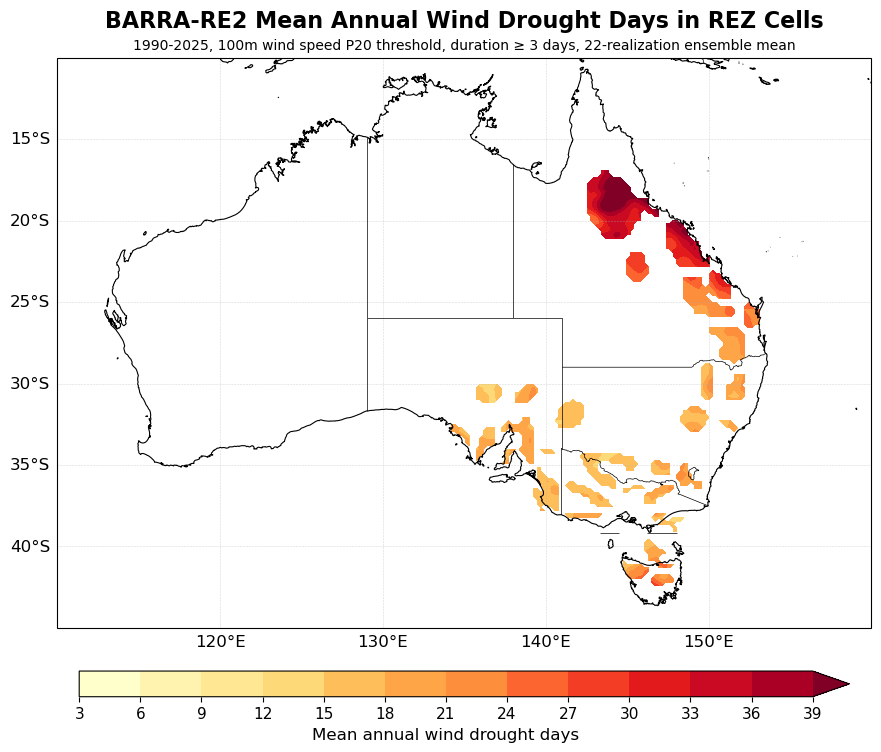

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/rez_region_analysis/BARRA_RE2_mean_annual_wind_drought_days_REZ_cells.png


In [7]:
# =====================
# Plot 1: BARRA-RE2 mean wind drought days over REZ cells
# =====================
cmap = plt.cm.YlOrRd.copy()
cmap.set_under("white")
cmap.set_bad("white")

norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

cf = ax.contourf(
    barra_rez_cells["lon"],
    barra_rez_cells["lat"],
    barra_rez_cells,
    levels=levels,
    cmap=cmap,
    norm=norm,
    extend="max",
    transform=ccrs.PlateCarree()
)

# Coastline
ax.coastlines(
    resolution="10m",
    linewidth=0.8,
    color="black",
    zorder=101
)

# State boundaries
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="black",
    linewidth=0.5,
    zorder=102
)

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar = plt.colorbar(
    cf,
    orientation="horizontal",
    pad=0.06,
    shrink=0.8,
    aspect=30
)

cbar.set_label("Mean annual wind drought days", fontsize=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=11)

ax.set_title(
    "BARRA-RE2 Mean Annual Wind Drought Days in REZ Cells",
    fontsize=16,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.01,
    "1990-2025, 100m wind speed P20 threshold, duration ≥ 3 days, 22-realization ensemble mean",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10
)

plt.tight_layout()

out_png_1 = os.path.join(
    output_dir,
    "BARRA_RE2_mean_annual_wind_drought_days_REZ_cells.png"
)

plt.savefig(out_png_1, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_png_1)

In [8]:
# =====================
# Calculate mean BARRA value for each REZ region
# =====================
region_mean_map = xr.full_like(barra_mean, np.nan, dtype="float32")
rows = []

for rid in unique_rez:
    region_mask = rez_on_barra == rid
    region_values = barra_mean.where(region_mask)

    mean_days = float(region_values.mean(skipna=True).values)
    median_days = float(region_values.median(skipna=True).values)
    min_days = float(region_values.min(skipna=True).values)
    max_days = float(region_values.max(skipna=True).values)
    n_cells = int(region_mask.sum().values)

    if np.isfinite(mean_days):
        region_mean_map = region_mean_map.where(~region_mask, other=mean_days)

    rows.append({
        "rez_id": int(rid),
        "n_barra_cells": n_cells,
        "mean_days": mean_days,
        "median_days": median_days,
        "min_days": min_days,
        "max_days": max_days,
    })

rez_stats = pd.DataFrame(rows).sort_values("rez_id").reset_index(drop=True)

out_csv = os.path.join(
    output_dir,
    "BARRA_RE2_mean_annual_wind_drought_days_by_REZ_region.csv"
)

rez_stats.to_csv(out_csv, index=False)

print(rez_stats)
print("Saved:", out_csv)

    rez_id  n_barra_cells  mean_days  median_days   min_days   max_days
0        1            227  36.022228    35.089649  24.203285  48.545456
1        2             23  37.571144    37.516415  33.496212  43.755051
2        3            114  32.877102    32.180557  26.748735  39.871216
3        4             50  27.210327    27.316917  24.752522  29.368690
4        5             46  27.395916    27.499371  22.537880  33.897728
5        6             31  23.839197    23.814394  20.756313  26.039145
6        7             82  20.420809    20.299873  18.292929  23.508837
7        8             99  22.840233    22.652779  19.935606  29.032827
8        9             40  18.653408    17.923613  16.261368  23.457069
9       10             40  19.171621    18.624367  17.362373  23.310606
10      11             49  18.067873    17.592171  15.429296  21.476011
11      12             57  15.830365    15.800505  14.510099  17.127525
12      13             51  15.363811    15.268940  14.563130  16

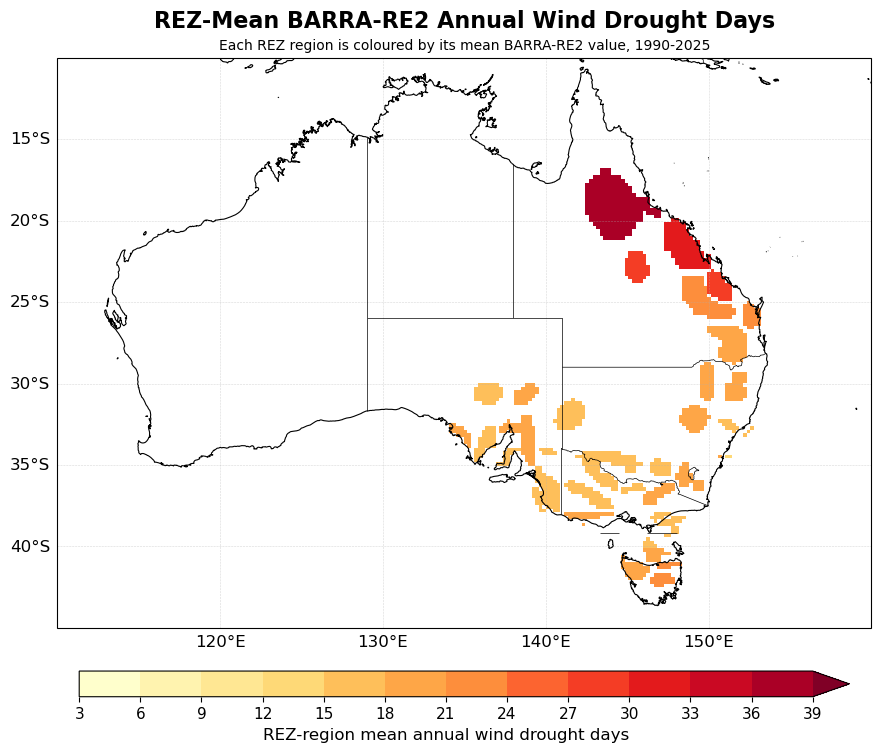

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/rez_region_analysis/BARRA_RE2_REZ_region_mean_annual_wind_drought_days.png


In [9]:
# =====================
# Plot 2: Each REZ region coloured by its BARRA-RE2 mean value
# =====================
cmap = plt.cm.YlOrRd.copy()
cmap.set_under("white")
cmap.set_bad("white")

norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

cf = ax.pcolormesh(
    region_mean_map["lon"],
    region_mean_map["lat"],
    region_mean_map,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree()
)

ax.coastlines(
    resolution="10m",
    linewidth=0.8,
    color="black",
    zorder=101
)

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="black",
    linewidth=0.5,
    zorder=102
)

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar = plt.colorbar(
    cf,
    orientation="horizontal",
    pad=0.06,
    shrink=0.8,
    aspect=30
)

cbar.set_label("REZ-region mean annual wind drought days", fontsize=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=11)

ax.set_title(
    "REZ-Mean BARRA-RE2 Annual Wind Drought Days",
    fontsize=16,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.01,
    "Each REZ region is coloured by its mean BARRA-RE2 value, 1990-2025",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10
)

plt.tight_layout()

out_png_2 = os.path.join(
    output_dir,
    "BARRA_RE2_REZ_region_mean_annual_wind_drought_days.png"
)

plt.savefig(out_png_2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_png_2)

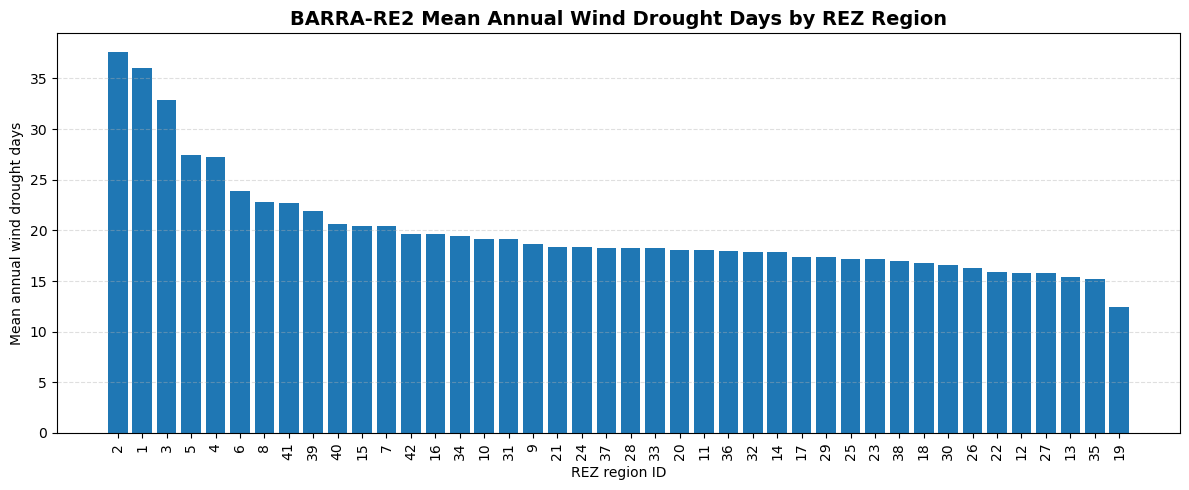

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/rez_region_analysis/BARRA_RE2_mean_annual_wind_drought_days_by_REZ_region_bar.png


In [10]:
# =====================
# Plot 3: Bar graph of BARRA-RE2 mean wind drought days by REZ region
# =====================
plot_df = rez_stats.sort_values("mean_days", ascending=False).copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    plot_df["rez_id"].astype(str),
    plot_df["mean_days"]
)

ax.set_xlabel("REZ region ID")
ax.set_ylabel("Mean annual wind drought days")
ax.set_title(
    "BARRA-RE2 Mean Annual Wind Drought Days by REZ Region",
    fontsize=14,
    fontweight="bold"
)

ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=90)
plt.tight_layout()

out_bar = os.path.join(
    output_dir,
    "BARRA_RE2_mean_annual_wind_drought_days_by_REZ_region_bar.png"
)

plt.savefig(out_bar, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_bar)

In [11]:
# =====================
# Save BARRA REZ products to NetCDF
# =====================
out_nc = os.path.join(
    output_dir,
    "BARRA_RE2_REZ_region_mean_wind_drought_days_1990_2025.nc"
)

out_ds = xr.Dataset(
    {
        "barra_mean_wind_drought_days_REZ_cells": barra_rez_cells,
        "barra_REZ_region_mean_wind_drought_days": region_mean_map,
        "rez_mask_on_barra_grid": rez_on_barra,
    }
)

out_ds.attrs["title"] = "BARRA-RE2 wind drought days over Australian REZ regions"
out_ds.attrs["description"] = (
    "BARRA-RE2 1990-2025 ensemble-mean climatological annual wind drought days, "
    "masked and summarised by REZ region. REZ mask was matched to the BARRA grid "
    "using nearest-neighbour interpolation."
)
out_ds.attrs["barra_file"] = barra_file
out_ds.attrs["rez_file"] = rez_file

encoding = {
    "barra_mean_wind_drought_days_REZ_cells": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "barra_REZ_region_mean_wind_drought_days": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "rez_mask_on_barra_grid": {"zlib": True, "complevel": 4, "dtype": "float32"},
}

out_ds.to_netcdf(out_nc, engine="netcdf4", encoding=encoding)

print("Saved:", out_nc)

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/rez_region_analysis/BARRA_RE2_REZ_region_mean_wind_drought_days_1990_2025.nc


In [12]:
# =====================
# Close datasets
# =====================
ds_barra.close()
ds_rez.close()
print("Done")

Done
